In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/raw/private_dataset.csv")

# Clean dataset (remove any hidden issues)
df = df.dropna()

# Check
print(df.isna().sum())

df.head()

record_id     0
age           0
zipcode       0
occupation    0
disease       0
dtype: int64


,record_id,age,zipcode,occupation,disease
2,2,46,27284,Teacher,Diabetes
3,3,32,27707,Engineer,Hypertension
4,4,60,27606,Teacher,Cancer
5,5,25,27401,Analyst,Diabetes
6,6,38,27284,Engineer,Cancer


# Attribute Inference Attack

Goal:
We want to predict a sensitive attribute (disease) using non-sensitive attributes.

Adversary knowledge:
- age
- zipcode
- occupation

Target:
- disease

If we can accurately predict disease, then privacy is compromised.

In [4]:
from sklearn.model_selection import train_test_split

# Features (attacker knowledge)
X = df[["age", "zipcode", "occupation"]]

# Target (sensitive)
y = df["disease"]

# Convert categorical → numeric
X_encoded = pd.get_dummies(X)

# FINAL safety clean
X_encoded = X_encoded.fillna(0)
y = y.fillna("None")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42
)

print("Data ready.")

Data ready.


In [6]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [8]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Attack Accuracy:", accuracy_score(y_test, y_pred))
print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred))

Attack Accuracy: 0.3511111111111111

Detailed Report:

              precision    recall  f1-score   support

      Cancer       0.30      0.31      0.31        77
    Diabetes       0.40      0.35      0.37        84
Hypertension       0.36      0.41      0.38        64

    accuracy                           0.35       225
   macro avg       0.35      0.35      0.35       225
weighted avg       0.35      0.35      0.35       225



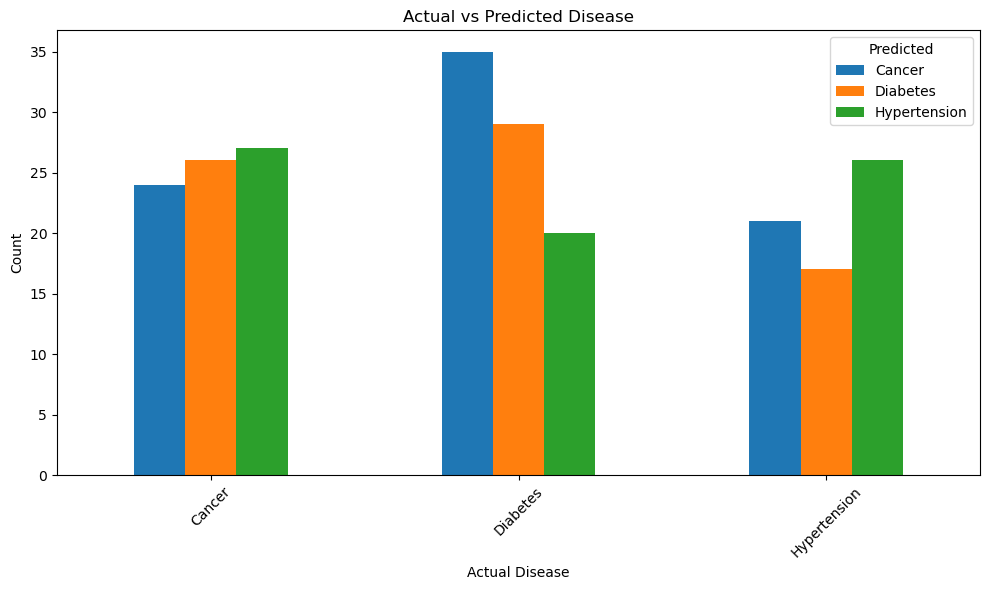

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

pd.crosstab(results["Actual"], results["Predicted"]).plot(kind="bar", figsize=(10,6))

plt.title("Actual vs Predicted Disease")
plt.xlabel("Actual Disease")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interpretation

The model can predict disease using only non-sensitive attributes.

This means:
- Sensitive information is leaking
- An attacker can infer private attributes
- The dataset is not privacy-preserving

This is a successful attribute inference attack.